In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

**Term Frequency (TF)** measures how frequently a term occurs in a document.
$$
Simple version: TF(t, d) = count of term t in document d.
Sometimes normalized: TF(t, d) = (count of t in d) / (total words in d).
$$

**Inverse Document Frequency (IDF)**
 measures how much information the word provides (i.e., whether it is common or rare across all documents).
$$
IDF(t, D) = log( total_documents / number_of_documents_containing_term_t ).
$$
The logarithm dampens the effect of very large numbers.

*TF‑IDF is then the product: TF‑IDF(t, d, D) = TF(t, d) × IDF(t, D).*

In [ ]:


corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are pets"
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

# Show the feature names
print(vectorizer.get_feature_names_out())
# Output: ['and' 'are' 'cat' 'cats' 'dog' 'dogs' 'log' 'mat' 'on' 'pets' 'sat' 'the']

# Show the TF‑IDF matrix as array and as a DataFrame
print("TF‑IDF matrix as array:")
Glows = (X.toarray())
df_features = pd.DataFrame(Glows)
print(df_features.head())

['and' 'are' 'cat' 'cats' 'dog' 'dogs' 'log' 'mat' 'on' 'pets' 'sat' 'the']
TF‑IDF matrix as array:
         0         1         2         3         4         5         6   \
0  0.000000  0.000000  0.427554  0.000000  0.000000  0.000000  0.000000   
1  0.000000  0.000000  0.000000  0.000000  0.427554  0.000000  0.427554   
2  0.447214  0.447214  0.000000  0.447214  0.000000  0.447214  0.000000   

         7         8         9         10        11  
0  0.427554  0.325166  0.000000  0.325166  0.650331  
1  0.000000  0.325166  0.000000  0.325166  0.650331  
2  0.000000  0.000000  0.447214  0.000000  0.000000  


In [70]:
# Load the dataset with the specified path and encoding
# We use r"" to handle the backslashes in the Windows file path
#df = pd.read_csv(r"E:\Spring 2026\Lab\Lab 05\spam.csv", encoding='latin-1')
# Only load the first two columns (index 0 and index 1)
df = pd.read_csv(r"E:\Spring 2026\Lab\Lab 05\spam.csv", 
                 encoding='latin-1', 
                 usecols=[0, 1])
# Assuming the CSV has columns named 'label' and 'message'
# If the column names are different, rename them to match the code below:
df = df.rename(columns={'v1': 'label', 'v2': 'message'}) 

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [71]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label"], test_size=0.2, random_state=42
)

In [72]:
# Step 5: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


Breakdown of the Code
Explain the two parameters:

**stop_words="english":** “Think of this as a ‘Trash Can’ for boring words. Words like ‘the’, ‘is’, ‘at’, and ‘which’ appear in every single email. They provide zero information about whether an email is spam. By setting this to ‘english’, we automatically throw those useless words away.”
****max_features=5000: ****“If we have 50,000 unique words, it makes the math really slow. We are telling the vectorizer: ‘Only keep the 5,000 most useful words.’ This keeps our computer from crashing and helps the model focus on the most important terms.”

In [73]:
# Step 6: Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [74]:
# Step 7: Predictions
y_pred = model.predict(X_test_tfidf)


In [75]:
# Step 8: Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam") # Use "spam" string here
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")



In [76]:
print("\n=== Evaluation Metrics ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))




=== Evaluation Metrics ===
Accuracy  : 0.9587
Precision : 0.9727
Recall    : 0.7133
F1 Score  : 0.8231

=== Classification Report ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       965
        Spam       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



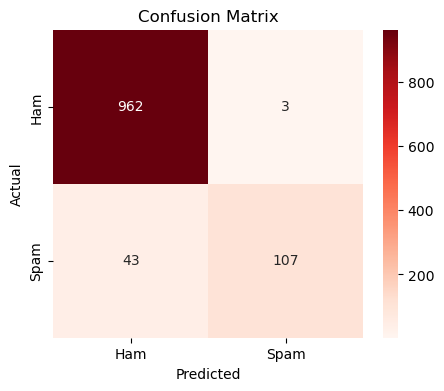

In [81]:
# Step 9: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
# Show students the difference

# Default settings (but we changed max_iter)
model1 = LogisticRegression(max_iter=1000)
print(model1)



# Show them the documentation
help(LogisticRegression)

LogisticRegression(max_iter=1000)
Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='deprecated', *, C=1.0, l1_ratio=0.0, dual=False, tol=0.0001, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, verbose=0, warm_start=False, n_jobs=None)
 |  
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |  
 |  This class implements regularized logistic regression using a set of available
 |  solvers. **Note that regularization is applied by default**. It can handle both
 |  dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted (and
 |  copied).
 |  
 |  The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only 

***C = 0.01 (very small) → Strong regularization → Simpler model (might underfit)
C = 1.0 (default) → Balanced regularization
C = 100 (large) → Weak regularization → Complex model (might overfit)***